In [86]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from koala import pointsets
from koala import graph_utils as gu

from tai_localiser.lauralizer.functions import bonds_func

from tai_localiser.perulizer import (
    proximity_bonds,
    randomly_rotate,
    sigma_y,
    proximity_lattice,
    bhz_ham,
    bhz_trs_operator,
    z2_spec_loc,
)
import pickle

import matplotlib

matplotlib.rcParams.update(
    {
        "font.size": 8,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
        # reduce border width of plots
        "axes.linewidth": 0.5,
        "lines.linewidth": 0.5,
    }
)

import cmasher

aps_figwidth = 6.6
aps_halfwidth = 3.375

In [87]:
from collections import Counter


def bond_lengths(bonds, points):
    return np.linalg.norm(points[bonds[:, 0]] - points[bonds[:, 1]], axis=1)


def coordinations(bonds, points):
    n_points = points.shape[0]
    counts_per_site = Counter(bonds.flatten())

    number_with_no_bonds = n_points - len(counts_per_site.keys())

    number_of_each_coord = Counter(counts_per_site.values())
    number_of_each_coord[0] = number_with_no_bonds

    return number_of_each_coord


def iterative_move_point(points_in, sigma, n_iterations, kappa, **kwargs):

    sigma_step = sigma / np.sqrt(n_iterations)
    kappa_step = kappa / n_iterations

    points = points_in.copy()
    for i in range(n_iterations):
        points = pointsets.move_all_points(points, sigma_step, kappa_step, **kwargs)

    return points

In [88]:
bond_distance = 1.3
disorder_average = 10

system_size_2d = 30
r0_2d = 1 / system_size_2d

system_size_3d = 10
r0_3d = 1 / system_size_3d


sigma_vals = np.linspace(0, 0.5, 20)
n_iterations = 3
beta = 1

rng = np.random.default_rng(43589)

grid_2d = pointsets.grid(system_size_2d, system_size_2d)
grid_3d = pointsets.grid(system_size_3d, system_size_3d, system_size_3d)

res_2d = 20
res_3d = 10

In [89]:
load = True

if load:
    with open(f"results/proximity_bonds_data_{n_iterations}_steps.pkl", "rb") as f:
        # with open(f"results/proximity_bonds_data.pkl", "rb") as f:
        data = pickle.load(f)
    p_out = data["p"]
    b_out = data["b"]
else:
    p_out = {"2d_0": [], "2d_3": [], "3d_0": [], "3d_3": []}
    b_out = {"2d_0": [], "2d_3": [], "3d_0": [], "3d_3": []}

    for sigma in tqdm(sigma_vals):

        p_2d_0 = []
        p_2d_3 = []
        p_3d_0 = []
        p_3d_3 = []

        b_2d_0 = []
        b_2d_3 = []
        b_3d_0 = []
        b_3d_3 = []

        for j in range(disorder_average):
            p_2d_0.append(
                iterative_move_point(
                    grid_2d,
                    sigma * r0_2d,
                    n_iterations,
                    0,
                    rng=rng,
                    resolution=res_2d,
                )
            )
            b_2d_0.append(bonds_func(p_2d_0[-1], bond_distance * r0_2d))

            p_2d_3.append(
                iterative_move_point(
                    grid_2d,
                    sigma * r0_2d,
                    n_iterations,
                    3 * r0_2d,
                    rng=rng,
                    resolution=res_2d,
                )
            )
            b_2d_3.append(bonds_func(p_2d_3[-1], bond_distance * r0_2d))

            p_3d_0.append(
                iterative_move_point(
                    grid_3d,
                    sigma * r0_3d,
                    n_iterations,
                    0,
                    rng=rng,
                    resolution=res_3d,
                )
            )
            b_3d_0.append(bonds_func(p_3d_0[-1], bond_distance * r0_3d))

            p_3d_3.append(
                iterative_move_point(
                    grid_3d,
                    sigma * r0_3d,
                    n_iterations,
                    3 * r0_3d,
                    rng=rng,
                    resolution=res_3d,
                )
            )
            b_3d_3.append(bonds_func(p_3d_3[-1], bond_distance * r0_3d))

        p_out["2d_0"].append(p_2d_0)
        p_out["2d_3"].append(p_2d_3)
        p_out["3d_0"].append(p_3d_0)
        p_out["3d_3"].append(p_3d_3)

        b_out["2d_0"].append(b_2d_0)
        b_out["2d_3"].append(b_2d_3)
        b_out["3d_0"].append(b_3d_0)
        b_out["3d_3"].append(b_3d_3)

In [90]:
# import pickle

# with open(f"results/proximity_bonds_data_{n_iterations}_steps.pkl", "wb") as f:
#     pickle.dump({"p": p_out, "b": b_out}, f)

(array([  1.,   5.,   8.,  23.,  40.,  71., 102., 139., 174., 239., 253.,
        272., 286., 300., 300., 312., 331., 313., 314., 300.]),
 array([0.60872186, 0.64327807, 0.67783427, 0.71239047, 0.74694668,
        0.78150288, 0.81605909, 0.85061529, 0.88517149, 0.9197277 ,
        0.9542839 , 0.98884011, 1.02339631, 1.05795251, 1.09250872,
        1.12706492, 1.16162113, 1.19617733, 1.23073353, 1.26528974,
        1.29984594]),
 <BarContainer object of 20 artists>)

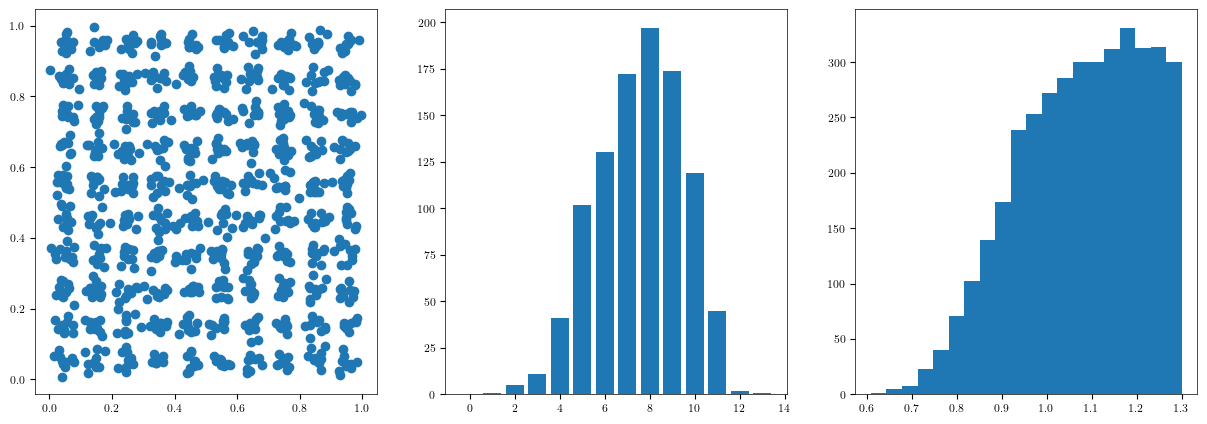

In [91]:
from collections import Counter

# sigma_n = 0
sigma_n -= 1
if sigma_n >= len(sigma_vals):
    sigma_n = 0

bonds = np.array(b_out["3d_3"][sigma_n][2])
points = np.array(p_out["3d_3"][sigma_n][2])


count = coordinations(bonds, points)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].scatter(points[:, 0], points[:, 1])
ax[1].bar(count.keys(), count.values())

bl = bond_lengths(bonds, points) / r0_3d

ax[2].hist(bl, bins=20)

In [92]:
counts_out = {"2d_0": [], "2d_3": [], "3d_0": [], "3d_3": []}
lengths_out = {"2d_0": [], "2d_3": [], "3d_0": [], "3d_3": []}

for s in tqdm(range(len(sigma_vals))):

    c_2d_0 = []
    c_2d_3 = []
    c_3d_0 = []
    c_3d_3 = []

    l_2d_0 = []
    l_2d_3 = []
    l_3d_0 = []
    l_3d_3 = []

    for j in range(disorder_average):

        bonds = np.array(b_out["2d_0"][s][j])
        points = np.array(p_out["2d_0"][s][j])

        c_2d_0.append(coordinations(bonds, points))
        l_2d_0.append(bond_lengths(bonds, points) / r0_2d)

        bonds = np.array(b_out["2d_3"][s][j])
        points = np.array(p_out["2d_3"][s][j])

        c_2d_3.append(coordinations(bonds, points))
        l_2d_3.append(bond_lengths(bonds, points) / r0_2d)

        bonds = np.array(b_out["3d_0"][s][j])
        points = np.array(p_out["3d_0"][s][j])

        c_3d_0.append(coordinations(bonds, points))
        l_3d_0.append(bond_lengths(bonds, points) / r0_3d)

        bonds = np.array(b_out["3d_3"][s][j])
        points = np.array(p_out["3d_3"][s][j])

        c_3d_3.append(coordinations(bonds, points))
        l_3d_3.append(bond_lengths(bonds, points) / r0_3d)

    # combine counters into one counter for each sigma value
    counts_out["2d_0"].append(sum(c_2d_0, Counter()))
    counts_out["2d_3"].append(sum(c_2d_3, Counter()))
    counts_out["3d_0"].append(sum(c_3d_0, Counter()))
    counts_out["3d_3"].append(sum(c_3d_3, Counter()))

    # combine lengths into one big list for each sigma value
    lengths_out["2d_0"].append(np.concatenate(l_2d_0))
    lengths_out["2d_3"].append(np.concatenate(l_2d_3))
    lengths_out["3d_0"].append(np.concatenate(l_3d_0))
    lengths_out["3d_3"].append(np.concatenate(l_3d_3))

100%|██████████| 20/20 [00:00<00:00, 25.93it/s]


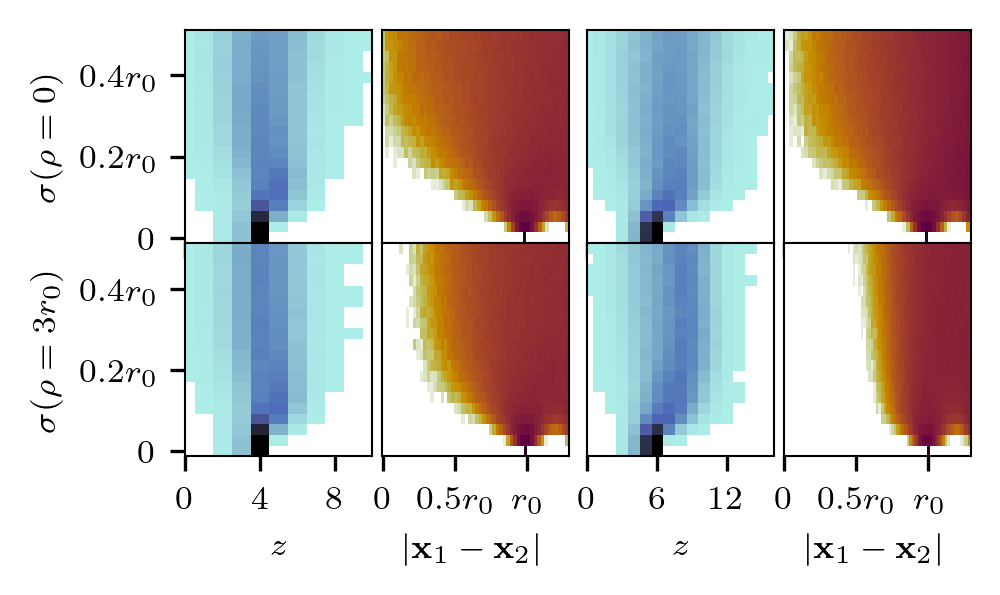

In [93]:
# use cmasher savanna_r
import cmasher

cmap = cmasher.sapphire_r
cmap2 = cmasher.fall_r


def plot_counts(counts, sigma_vals, ax, cmap=cmap):
    # print(counts)
    combined_keys = tuple(set(k for c in counts for k in c.keys()))
    array_counts = np.array([[c[k] for k in combined_keys] for c in counts])

    alphas = 1 - (array_counts == 0)

    k, si = np.meshgrid(combined_keys, sigma_vals)
    im = ax.pcolormesh(k, si, array_counts, shading="nearest", cmap=cmap, alpha=alphas)


def plot_distances(lengths, sigma_vals, ax):

    # make_bins
    ma = max(l.max() for l in lengths)
    mi = min(l.min() for l in lengths)
    bins = np.linspace(mi, ma, 50)

    hists = np.array([np.histogram(l, bins)[0] for l in lengths])
    k, si = np.meshgrid(bins[:-1], sigma_vals)
    im = ax.pcolormesh(
        k, si, hists, shading="nearest", cmap=cmap2, norm=matplotlib.colors.LogNorm()
    )


fig, ax = plt.subplot_mosaic(
    """
    a.b.c.d
    e.f.g.h
    """,
    figsize=(aps_halfwidth, aps_halfwidth * 0.6),
    dpi=300,
    gridspec_kw={"hspace": 0.0, "wspace": 0.0},
    width_ratios=[1, 0.05, 1, 0.1, 1, 0.05, 1],
)


plot_counts(counts_out["2d_0"], sigma_vals, ax["a"])
plot_counts(counts_out["2d_3"], sigma_vals, ax["e"])
ax["e"].sharex(ax["a"])

plot_counts(counts_out["3d_0"], sigma_vals, ax["c"])
plot_counts(counts_out["3d_3"], sigma_vals, ax["g"])
ax["g"].sharex(ax["c"])

plot_distances(lengths_out["2d_0"], sigma_vals, ax["b"])
plot_distances(lengths_out["2d_3"], sigma_vals, ax["f"])
ax["f"].sharex(ax["b"])

plot_distances(lengths_out["3d_0"], sigma_vals, ax["d"])
plot_distances(lengths_out["3d_3"], sigma_vals, ax["h"])
ax["h"].sharex(ax["d"])

for a in ax.keys():
    ax[a].set_xticks([])

    if a not in ["a", "e"]:
        ax[a].set_yticks([])

        # plt.setp(ax[a].get_xticklabels(), visible=False)

    if a in ["a", "e"]:
        ax[a].set_yticks([0, 0.2, 0.4])
        ax[a].set_yticklabels([0, f"0.2$r_0$", f"0.4$r_0$"])
    if a in ["a"]:
        ax[a].set_ylabel(r"$\sigma (\rho = 0)$")
    if a in ["e"]:
        ax[a].set_ylabel(r"$\sigma (\rho = 3r_0)$")

    if a in ["e"]:
        ax[a].set_xticks(np.arange(3) * 4)
        ax[a].set_xlabel("$z$")
        ax[a].set_xlim(0, 10)
    if a in ["g"]:
        ax[a].set_xticks(np.arange(3) * 6)
        ax[a].set_xlabel("$z$")
        ax[a].set_xlim(0, 16)

    if a in ["f", "h"]:
        ax[a].set_xticks([0, 0.5, 1])
        ax[a].set_xticklabels(["0", f"$0.5r_0$", f"$r_0$"])
        ax[a].set_xlabel(f"$|\\textbf x_1 - \\textbf x_2|$")

    if a in ["a", "b", "c", "d"]:
        ax[a].tick_params(labelbottom=False)

plt.tight_layout()
plt.savefig("connectivity.png", bbox_inches="tight", dpi=350)
plt.show()